# Data-Driven Study of AQI Variation in Indian Metropolitan Cities

**Files assumed present in** '' (same folder):
- `delhi_combined.csv`, `mumbai_combined.csv`, `bengaluru_combined.csv`, `chennai_combined.csv`, `hyderabad_combined.csv`


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from scipy import stats
import json, os
print('Libraries loaded')


Libraries loaded


In [2]:

data_dir = Path('')
output_dir = Path('air_project_outputs')
output_dir.mkdir(parents=True, exist_ok=True)

city_files = {
    'Delhi':'delhi_combined.csv',
    'Mumbai':'mumbai_combined.csv',
    'Bengaluru':'bengaluru_combined.csv',
    'Chennai': 'chennai_combined.csv',
    'Hyderabad':'hyderabad_combined.csv'
}

dfs = []
for city, path in city_files.items():
    p = Path(path) 
    if p.exists():
        print('Loading', p)
        df = pd.read_csv(p)
        df['City'] = city
        dfs.append(df)
    else:
        print('File not found:', p)


if not dfs:
    raise FileNotFoundError('No city CSVs found. Upload the five CSVs first.')

raw = pd.concat(dfs, ignore_index=True)
print('Combined shape:', raw.shape)


Loading delhi_combined.csv
Loading mumbai_combined.csv
Loading bengaluru_combined.csv
Loading chennai_combined.csv
Loading hyderabad_combined.csv
Combined shape: (9135, 10)


In [3]:

print(raw.columns.tolist()[:50])

ts_candidates = [c for c in raw.columns if 'time' in c.lower() or 'date' in c.lower() or 'timestamp' in c.lower()]
print('Timestamp candidates:', ts_candidates)
ts_col = ts_candidates[0] if ts_candidates else None
if ts_col is None:
    raise ValueError('No timestamp-like column detected. Please ensure your CSVs contain a date/time column.')
print('Using timestamp column:', ts_col)


['Timestamp', 'Location', 'PM2.5', 'PM10', 'NO2', 'NH3', 'SO2', 'CO', 'O3', 'City']
Timestamp candidates: ['Timestamp']
Using timestamp column: Timestamp


In [4]:

# Parse datetime and create standard pollutant columns
df = raw.copy()
df['datetime'] = pd.to_datetime(df[ts_col], errors='coerce', dayfirst=True)
if df['datetime'].isna().mean() > 0.2:
    df['datetime'] = pd.to_datetime(df[ts_col], errors='coerce', infer_datetime_format=True)
print('Datetime parse NA fraction:', df['datetime'].isna().mean())

def clean_numeric(series):
    s = series.astype(str).str.strip().replace({'None':np.nan,'none':np.nan,'-':np.nan,'--':np.nan,'NA':np.nan,'na':np.nan,'':np.nan,'nan':np.nan})
    return pd.to_numeric(s, errors='coerce')

cols_lower = {c.lower():c for c in df.columns}
def find_col(possible):
    for p in possible:
        if p in cols_lower:
            return cols_lower[p]
    return None

pm25_col = find_col(['pm2.5','pm25','pm_2.5','pm_2_5'])
pm10_col = find_col(['pm10','pm_10'])
no2_col = find_col(['no2','n02','no_2'])
so2_col = find_col(['so2','so_2'])
co_col = find_col(['co'])
o3_col = find_col(['o3','ozone'])
nh3_col = find_col(['nh3'])

df['PM2.5'] = clean_numeric(df[pm25_col]) if pm25_col else np.nan
df['PM10'] = clean_numeric(df[pm10_col]) if pm10_col else np.nan
df['NO2'] = clean_numeric(df[no2_col]) if no2_col else np.nan
df['SO2'] = clean_numeric(df[so2_col]) if so2_col else np.nan
df['CO']  = clean_numeric(df[co_col]) if co_col else np.nan
df['O3']  = clean_numeric(df[o3_col]) if o3_col else np.nan
df['NH3'] = clean_numeric(df[nh3_col]) if nh3_col else np.nan

print('Pollutant columns standardized. Example:')
df[['datetime','City','PM2.5','PM10','NO2','SO2','CO','O3','NH3']].head()


Datetime parse NA fraction: 0.0
Pollutant columns standardized. Example:


,datetime,City,PM2.5,PM10,NO2,SO2,CO,O3,NH3
0,2020-01-01,Delhi,420.68,507.60,105.21,6.30,2.26,9.49,63.96
1,2020-01-02,Delhi,364.73,480.09,79.38,9.69,2.87,8.03,51.28
2,2020-01-03,Delhi,227.72,309.23,57.22,11.04,2.69,8.18,44.29
3,2020-01-04,Delhi,243.86,323.75,60.99,12.61,1.94,11.72,44.88
4,2020-01-05,Delhi,161.66,222.79,56.22,11.03,1.91,12.37,38.35


In [5]:

# Drop rows without datetime and set index
df = df.dropna(subset=['datetime']).reset_index(drop=True)
df = df.sort_values(['City','datetime']).reset_index(drop=True)
df = df.set_index('datetime')
print('After dropping NA datetime, shape:', df.shape)


After dropping NA datetime, shape: (9135, 10)


In [6]:

# Missing values before
pollutants = ['PM2.5','PM10','NO2','SO2','CO','O3','NH3']
missing_before = df[pollutants].isna().sum()
print('Missing before:\n', missing_before)

# Interpolate and smooth per city
filled_list = []
for city in df['City'].unique():
    sub = df[df['City']==city].copy()
    sub = sub.sort_index()
    sub[pollutants] = sub[pollutants].interpolate(method='time', limit_direction='both')
    sub[pollutants] = sub[pollutants].ffill().bfill().fillna(0)
    for p in pollutants:
        sub[p+'_smoothed'] = sub[p].rolling(window=3, min_periods=1).median()
    filled_list.append(sub)

clean = pd.concat(filled_list).sort_index()
missing_after = clean[pollutants].isna().sum()
print('Missing after interpolation/fill:\n', missing_after)


Missing before:
 PM2.5    271
PM10     650
NO2      259
SO2      352
CO       186
O3       288
NH3      735
dtype: int64
Missing after interpolation/fill:
 PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
NH3      0
dtype: int64


In [7]:

# Save cleaned hourly and daily datasets
# Ensure Date is datetime
# Check if datetime is already index
if 'datetime' not in clean.columns:
    clean = clean.reset_index()

# Ensure datetime column exists and convert it
datetime_col = None
for col in clean.columns:
    if col.lower() in ['datetime', 'date', 'timestamp']:
        datetime_col = col
        break

if datetime_col is None:
    raise KeyError("No datetime column found in dataframe! Check column names.")

# Convert to datetime
clean[datetime_col] = pd.to_datetime(clean[datetime_col], errors='coerce')

# Set index
clean = clean.set_index(datetime_col)

# numeric columns only
num_cols = clean.select_dtypes(include='number').columns

# daily mean per city
daily = clean.groupby('City')[num_cols].resample('D').mean().reset_index()

# save files
clean.reset_index().to_csv(output_dir/'cleaned_hourly_combined.csv', index=False)
daily.to_csv(output_dir/'cleaned_daily_combined.csv', index=False)

print(" Saved hourly & daily cleaned files!")


 Saved hourly & daily cleaned files!


In [8]:

# Data dictionary
data_dict = []
for c in clean.columns:
    data_dict.append({'feature':c, 'dtype':str(clean[c].dtype), 'missing_after':int(clean[c].isna().sum())})
ddf = pd.DataFrame(data_dict)
ddf.to_csv(output_dir/'data_dictionary.csv', index=False)
ddf.head()


,feature,dtype,missing_after
0,Timestamp,object,0
1,Location,object,0
2,PM2.5,float64,0
3,PM10,float64,0
4,NO2,float64,0


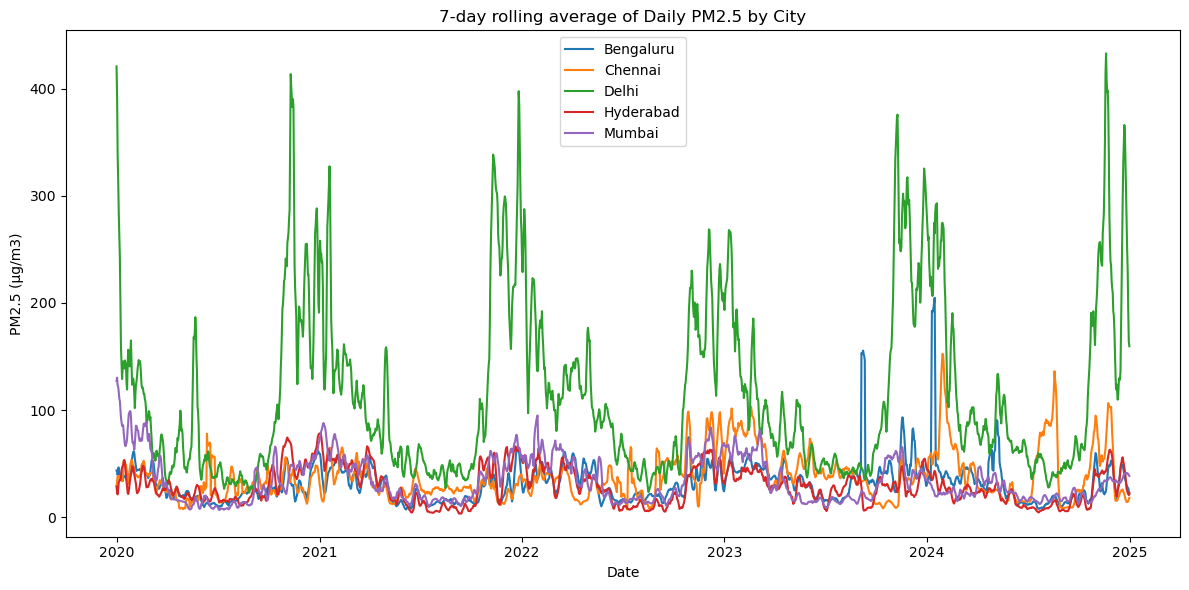

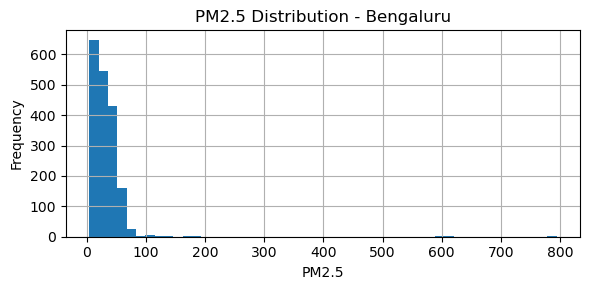

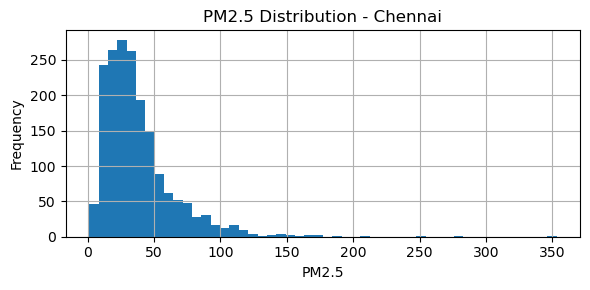

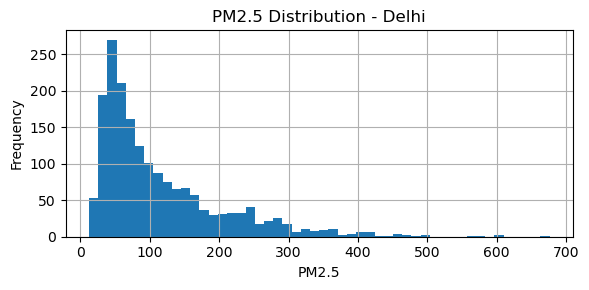

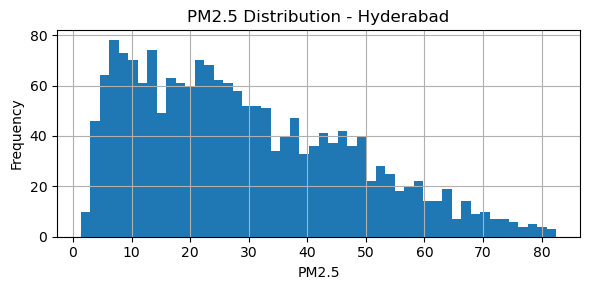

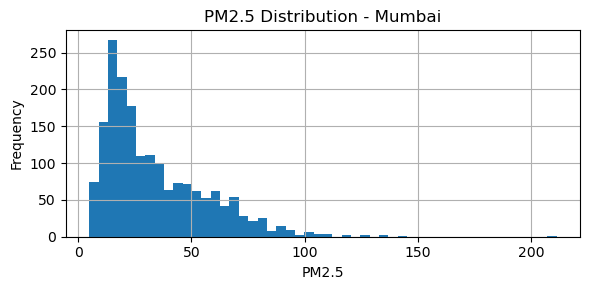

<Figure size 800x500 with 0 Axes>

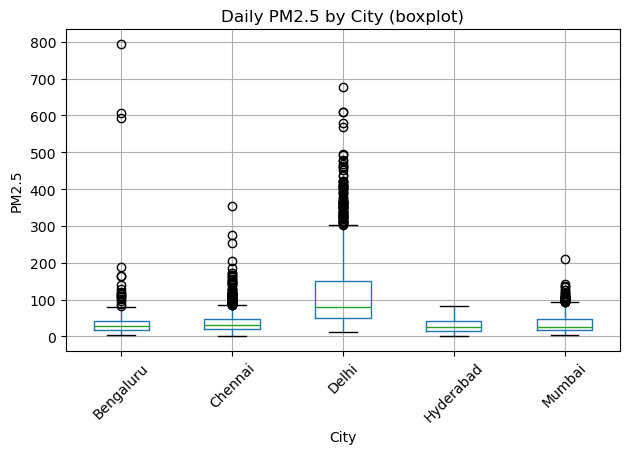

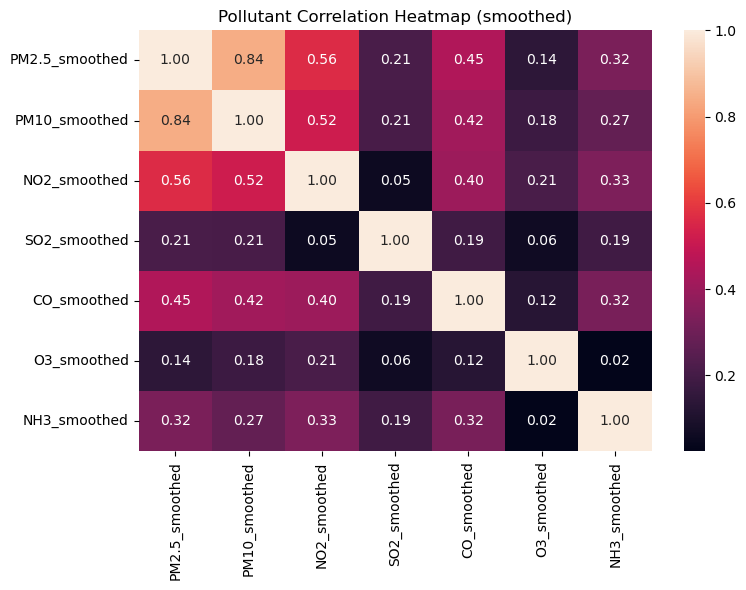

In [9]:

# EDA Visualizations (trends, histograms, boxplots, heatmap)
plt.figure(figsize=(12,6))
for city in daily['City'].unique():
    s = daily[daily['City']==city].set_index('datetime')['PM2.5'].rolling(7,min_periods=1).mean()
    plt.plot(s.index, s.values, label=city)
plt.legend(); plt.title('7-day rolling average of Daily PM2.5 by City'); plt.xlabel('Date'); plt.ylabel('PM2.5 (µg/m3)')
plt.tight_layout(); plt.savefig(output_dir/'pm25_trend_cities.png'); plt.show()

for city in daily['City'].unique():
    plt.figure(figsize=(6,3))
    daily[daily['City']==city]['PM2.5'].hist(bins=50)
    plt.title(f'PM2.5 Distribution - {city}'); plt.xlabel('PM2.5'); plt.ylabel('Frequency')
    plt.tight_layout(); plt.savefig(output_dir/f'pm25_hist_{city}.png'); plt.show()

plt.figure(figsize=(8,5))
daily.boxplot(column='PM2.5', by='City', rot=45)
plt.title('Daily PM2.5 by City (boxplot)'); plt.suptitle(''); plt.ylabel('PM2.5')
plt.tight_layout(); plt.savefig(output_dir/'pm25_boxplot_cities.png'); plt.show()

sm_cols = [p+'_smoothed' for p in pollutants if p+'_smoothed' in clean.columns]
if sm_cols:
    plt.figure(figsize=(8,6))
    sns.heatmap(clean[sm_cols].corr(), annot=True, fmt='.2f')
    plt.title('Pollutant Correlation Heatmap (smoothed)')
    plt.tight_layout(); plt.savefig(output_dir/'pollutant_correlation_heatmap.png'); plt.show()


In [10]:

# Day/night & weekend analysis
hr = clean.reset_index().copy()
hr['hour'] = hr.index.hour if hr.index.dtype == 'datetime64[ns]' else hr['datetime'].dt.hour
hr['is_day'] = hr['hour'].between(6,18)
hr['weekday'] = hr.index.weekday if hr.index.dtype == 'datetime64[ns]' else hr['datetime'].dt.weekday
hr['is_weekend'] = hr['weekday']>=5

daynight_stats = hr.groupby(['City','is_day'])['PM2.5'].agg(['mean','std','count']).reset_index()
daynight_stats.to_csv(output_dir/'day_night_pm25_stats.csv', index=False)
daynight_stats.head()

tests = []
for city in hr['City'].unique():
    sub = hr[hr['City']==city]
    wkend = sub[sub['is_weekend']]['PM2.5'].dropna()
    wkday = sub[~sub['is_weekend']]['PM2.5'].dropna()
    if len(wkend)>30 and len(wkday)>30:
        tstat, pval = stats.ttest_ind(wkend, wkday, equal_var=False, nan_policy='omit')
    else:
        tstat, pval = np.nan, np.nan
    tests.append({'City':city,'tstat':tstat,'pvalue':pval,'wkend_mean':wkend.mean() if len(wkend)>0 else None,'wkday_mean':wkday.mean() if len(wkday)>0 else None})
tt = pd.DataFrame(tests)
tt.to_csv(output_dir/'weekend_weekday_ttests_pm25.csv', index=False)
tt


,City,tstat,pvalue,wkend_mean,wkday_mean
0,Bengaluru,-2.415139,0.015832,29.624711,32.668832
1,Mumbai,-0.238393,0.811631,33.757000,34.048848
2,Chennai,-0.660148,0.509322,37.378856,38.346549
3,Delhi,-0.054085,0.956879,113.550310,113.802270
4,Hyderabad,-0.275504,0.782989,28.829722,29.087368


In [11]:

# 95% CI for mean PM2.5 per city
ci_list = []
for city in hr['City'].unique():
    vals = hr[hr['City']==city]['PM2.5'].dropna().values
    n = len(vals)
    if n>10:
        mean = vals.mean()
        se = stats.sem(vals, nan_policy='omit')
        try:
            ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
        except Exception:
            ci = (None,None)
    else:
        mean, ci = (None,(None,None))
    ci_list.append({'City':city,'mean_pm25':float(mean) if mean is not None else None,'ci_lower':ci[0],'ci_upper':ci[1],'n':n})
ci_df = pd.DataFrame(ci_list)
ci_df.to_csv(output_dir/'pm25_confidence_intervals.csv', index=False)
ci_df


,City,mean_pm25,ci_lower,ci_upper,n
0,Bengaluru,31.799083,30.352032,33.246135,1827
1,Mumbai,33.965463,32.920725,35.010200,1827
2,Chennai,38.070066,36.788488,39.351643,1827
3,Delhi,113.730282,109.563705,117.896858,1827
4,Hyderabad,29.013755,28.185303,29.842207,1827


##  Two-Sample Z-Test: Delhi vs Mumbai AQI

In [12]:
# Compute AQI if not already done
def compute_aqi(pm25):
    # Simplified AQI category mapping for India scale
    if pm25 <= 50: return 50
    elif pm25 <= 100: return 100
    elif pm25 <= 200: return 200
    elif pm25 <= 300: return 300
    elif pm25 <= 400: return 400
    else: return 500

daily['AQI'] = daily['PM2.5'].apply(compute_aqi)


In [13]:
delhi = daily[daily['City']=="Delhi"]['AQI'].dropna()
mumbai = daily[daily['City']=="Mumbai"]['AQI'].dropna()

mean_diff = delhi.mean() - mumbai.mean()
std_error = np.sqrt(delhi.var()/len(delhi) + mumbai.var()/len(mumbai))
z_score = mean_diff / std_error

z_score


35.529129457047496

##  Two-Sample T-Test (Welch's)

In [14]:

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(delhi, mumbai, equal_var=False)
t_stat, p_val


(35.52912945704771, 3.7629127639205267e-216)

##  Chi-Square Test: Pollution Category vs City

In [15]:

from scipy.stats import chi2_contingency

daily['AQI_Category'] = pd.cut(daily['AQI'], bins=[0,100,200,300,500], 
                               labels=["Good","Moderate","Poor","Very Poor"])

table = pd.crosstab(daily['City'], daily['AQI_Category'])
chi2_contingency(table)


Chi2ContingencyResult(statistic=2772.105223671244, pvalue=0.0, dof=12, expected_freq=array([[1656.2,  111. ,   42.4,   17.4],
       [1656.2,  111. ,   42.4,   17.4],
       [1656.2,  111. ,   42.4,   17.4],
       [1656.2,  111. ,   42.4,   17.4],
       [1656.2,  111. ,   42.4,   17.4]]))

##  Moving Average AQI Forecast (7 & 30 days)

In [16]:

delhi_ma7 = delhi.rolling(7).mean()
delhi_ma30 = delhi.rolling(30).mean()

delhi_ma7.tail(), delhi_ma30.tail()


(5476    300.000000
 5477    285.714286
 5478    242.857143
 5479    214.285714
 5480    200.000000
 Name: AQI, dtype: float64,
 5476    266.666667
 5477    263.333333
 5478    256.666667
 5479    250.000000
 5480    250.000000
 Name: AQI, dtype: float64)

PCA candidate columns: ['PM2.5_smoothed', 'PM10_smoothed', 'NO2_smoothed', 'SO2_smoothed', 'CO_smoothed', 'O3_smoothed', 'NH3_smoothed']
Explained variance ratio: [0.42288354 0.14609398 0.13440213]


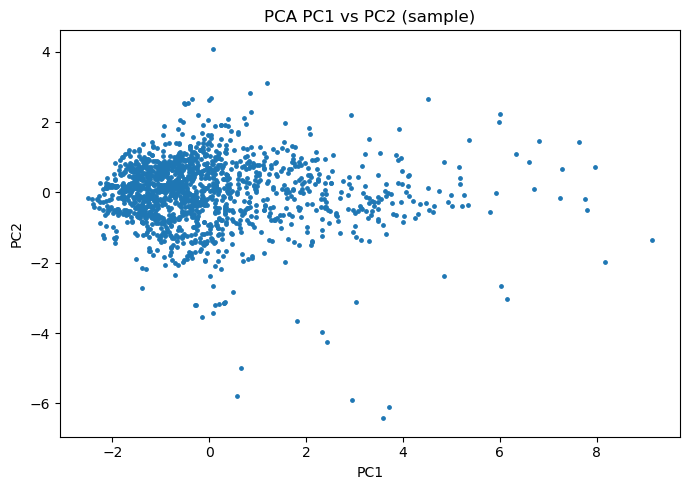

In [17]:

# PCA on smoothed pollutant columns
pca_cols = [c for c in clean.columns if c.endswith('_smoothed')]
print('PCA candidate columns:', pca_cols)
pca_input = clean[pca_cols].dropna()
if len(pca_input)>10:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(pca_input)
    pca = PCA(n_components=min(3, scaled.shape[1]))
    pcs = pca.fit_transform(scaled)
    evr = pca.explained_variance_ratio_
    print('Explained variance ratio:', evr)
    json.dump(
        {"explained_variance_ratio": evr.tolist()},
        open(output_dir/'pca_explained.json','w')
    )
    idx = np.random.choice(range(pcs.shape[0]), size=min(1500, pcs.shape[0]), replace=False)
    plt.figure(figsize=(7,5)); plt.scatter(pcs[idx,0], pcs[idx,1], s=6); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA PC1 vs PC2 (sample)'); plt.tight_layout(); plt.savefig(output_dir/'pca_comp1_comp2.png'); plt.show()
else:
    print('Not enough rows for PCA')    


In [18]:

# Apriori-style pairwise rules (High if >75th percentile per city)
rules = []
for city in clean['City'].unique():
    sub = clean[clean['City']==city]
    cols = [c for c in sub.columns if c.endswith('_smoothed')]
    if len(cols)<2: continue
    thresh = sub[cols].quantile(0.75)
    bin_df = (sub[cols] > thresh).astype(int).dropna()
    n = len(bin_df)
    for a,b in combinations(bin_df.columns,2):
        support = ((bin_df[a]==1) & (bin_df[b]==1)).sum()/n if n>0 else 0
        support_a = (bin_df[a]==1).sum()/n if n>0 else 0
        support_b = (bin_df[b]==1).sum()/n if n>0 else 0
        if support>0.05:
            conf = support/support_a if support_a>0 else 0
            lift = conf/support_b if support_b>0 else None
            rules.append({'city':city,'antecedent':a.replace('_smoothed',''),'consequent':b.replace('_smoothed',''),'support':support,'confidence':conf,'lift':lift})
rules_df = pd.DataFrame(rules)
rules_df.to_csv(output_dir/'apriori_simple_rules.csv', index=False)
rules_df.head()


,city,antecedent,consequent,support,confidence,lift
0,Bengaluru,PM2.5,PM10,0.152162,0.608315,2.437262
1,Bengaluru,PM2.5,NO2,0.089765,0.358862,1.434663
2,Bengaluru,PM2.5,SO2,0.064587,0.258206,1.032258
3,Bengaluru,PM2.5,CO,0.068418,0.273523,1.122981
4,Bengaluru,PM2.5,O3,0.070060,0.280088,1.122193


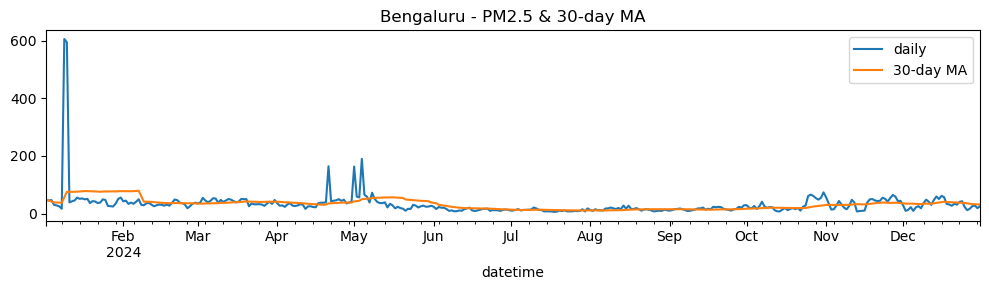

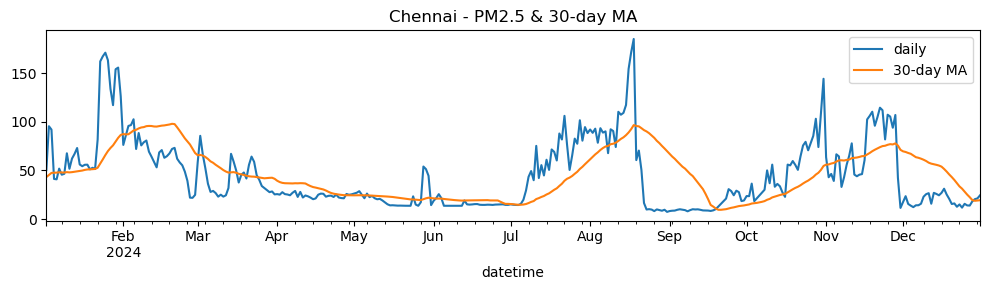

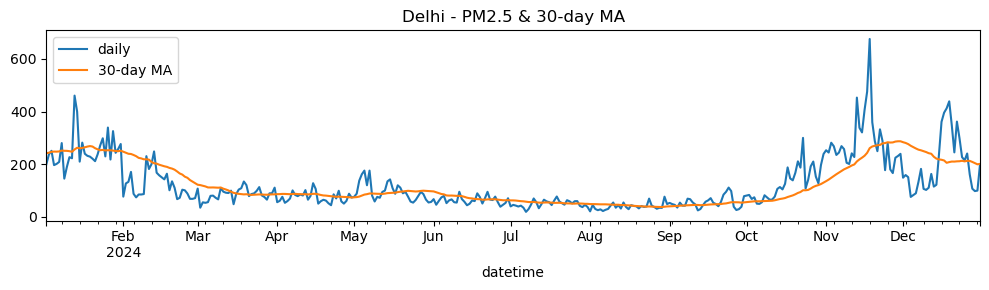

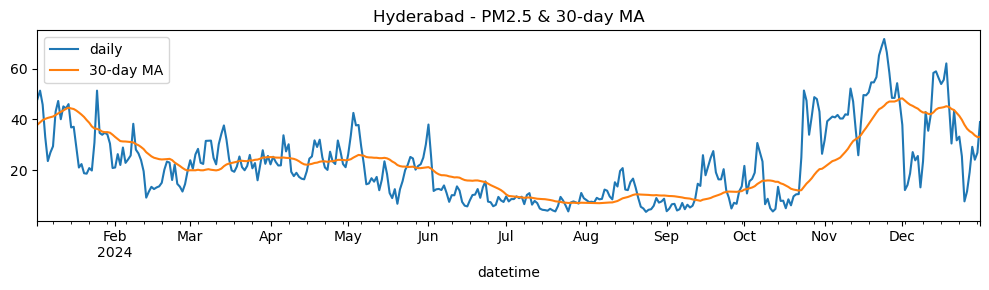

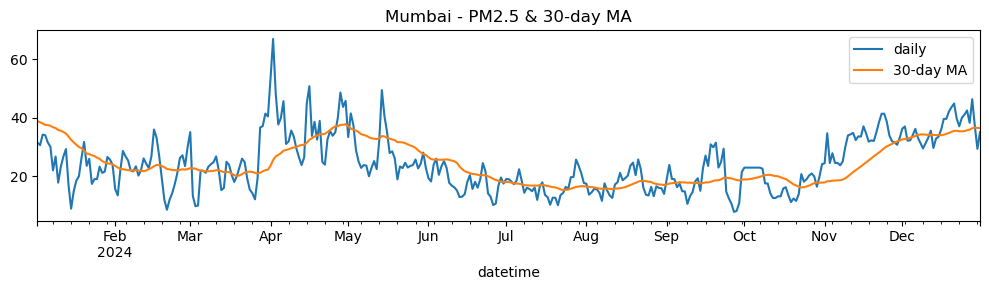

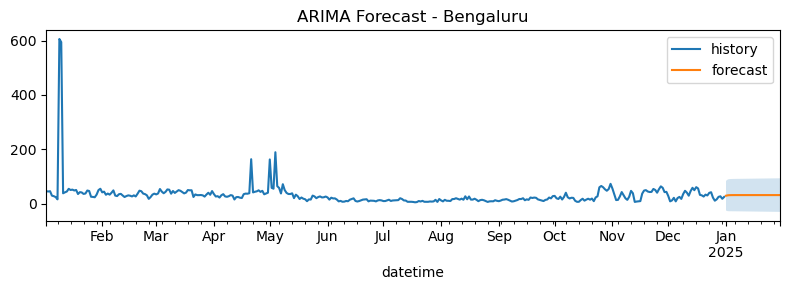

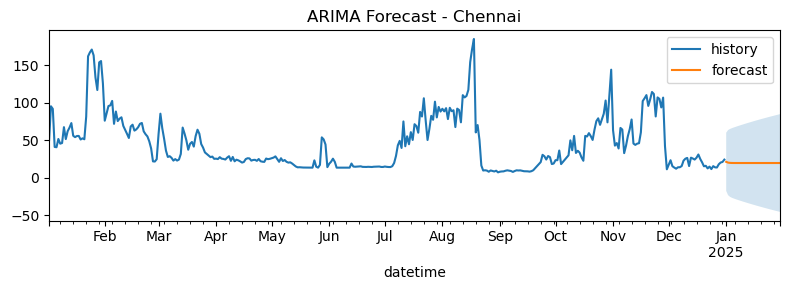

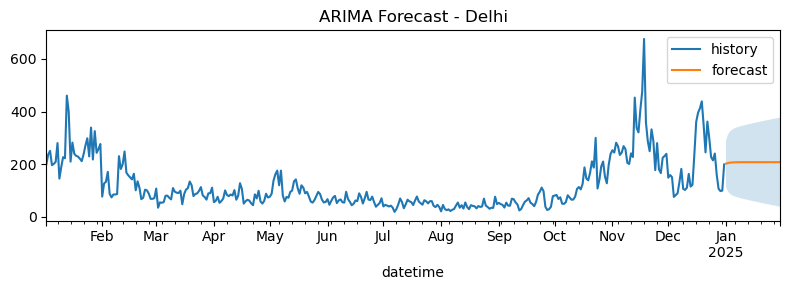

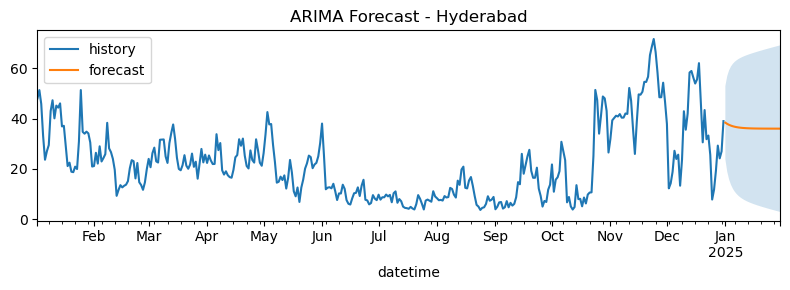

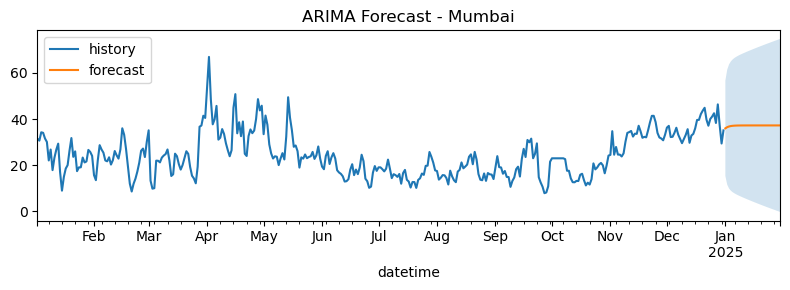

ARIMA summary saved


In [19]:

# Time-series smoothing and forecasting (MA + ARIMA if available)
import warnings
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")

for city in daily['City'].unique():
    ser = (
        daily[daily['City'] == city]
        .set_index('datetime')['PM2.5']
        .asfreq('D')
        .interpolate()
        .ffill()
        .bfill()
    )
    ser_ma = ser.rolling(30, min_periods=3).mean()
    plt.figure(figsize=(10,3))
    ser[-365:].plot(label='daily')
    ser_ma[-365:].plot(label='30-day MA')
    plt.legend()
    plt.title(f'{city} - PM2.5 & 30-day MA')
    plt.tight_layout()
    plt.savefig(output_dir/f'forecast_ma_{city}.png')
    plt.show()

try:
    import statsmodels.api as sm
    arima_available = True
except:
    arima_available = False

if arima_available:
    arima_summary = {}
    for city in daily['City'].unique():
        ser = (
            daily[daily['City'] == city]
            .set_index('datetime')['PM2.5']
            .asfreq('D')
            .interpolate()
            .ffill()
            .bfill()
        )
        if ser.dropna().shape[0] > 365:
            try:
                mod = sm.tsa.ARIMA(ser, order=(1,1,1))
                res = mod.fit()
                pred = res.get_forecast(30)
                pred_ci = pred.conf_int()
                forecast = pred.predicted_mean

                plt.figure(figsize=(8,3))
                ser[-365:].plot(label='history')
                forecast.plot(label='forecast')
                plt.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], alpha=0.2)
                plt.legend()
                plt.title(f'ARIMA Forecast - {city}')
                plt.tight_layout()
                plt.savefig(output_dir/f'arima_forecast_{city}.png')
                plt.show()

                arima_summary[city] = {'status': 'fitted', 'aic': res.aic}
            except Exception as e:
                arima_summary[city] = {'status': 'failed', 'error': str(e)}
        else:
            arima_summary[city] = {'status': 'insufficient_data'}
    json.dump(arima_summary, open(output_dir/'arima_summary.json','w'))
    print('ARIMA summary saved')
